In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
from sklearn.model_selection import GridSearchCV
import joblib

In [2]:
df = pd.read_csv("bank_transaction_risk_dataset_10000.csv")
df

,transaction_id,user_id,amount,transaction,merchant,country,hour,device_risk,ip_risk_score,is_fraud
0,5506,350,1878.96,QR,Travel,US,5,0.618457,0.441876,1
1,7912,132,2997.31,ATM,Food,UK,7,0.109852,0.102037,1
2,4257,833,299.84,POS,Travel,DE,5,0.564353,0.364658,1
3,3615,814,3543.28,POS,Clothing,FR,5,0.023174,0.582247,1
4,2674,194,4163.89,POS,Food,FR,15,0.145897,0.117277,1
...,...,...,...,...,...,...,...,...,...,...
9995,5670,168,3042.46,POS,Travel,TR,17,0.412330,0.063435,1
9996,9294,786,2334.37,ATM,Food,FR,10,0.176828,0.285607,1
9997,6697,204,3887.58,QR,Food,US,10,0.111286,0.082749,1
9998,5625,490,1353.89,QR,Travel,US,21,0.619456,0.451216,1


In [3]:
df.head()

,transaction_id,user_id,amount,transaction,merchant,country,hour,device_risk,ip_risk_score,is_fraud
0,5506,350,1878.96,QR,Travel,US,5,0.618457,0.441876,1
1,7912,132,2997.31,ATM,Food,UK,7,0.109852,0.102037,1
2,4257,833,299.84,POS,Travel,DE,5,0.564353,0.364658,1
3,3615,814,3543.28,POS,Clothing,FR,5,0.023174,0.582247,1
4,2674,194,4163.89,POS,Food,FR,15,0.145897,0.117277,1


In [4]:
df.tail()

,transaction_id,user_id,amount,transaction,merchant,country,hour,device_risk,ip_risk_score,is_fraud
9995,5670,168,3042.46,POS,Travel,TR,17,0.412330,0.063435,1
9996,9294,786,2334.37,ATM,Food,FR,10,0.176828,0.285607,1
9997,6697,204,3887.58,QR,Food,US,10,0.111286,0.082749,1
9998,5625,490,1353.89,QR,Travel,US,21,0.619456,0.451216,1
9999,7160,478,107.08,Online,Grocery,UK,18,0.266643,0.161865,1


In [5]:
print(df.shape)

(10000, 10)


In [6]:
print(df.isnull().sum())

transaction_id    0
user_id           0
amount            0
transaction       0
merchant          0
country           0
hour              0
device_risk       0
ip_risk_score     0
is_fraud          0
dtype: int64


In [7]:
df = df.drop_duplicates()

In [8]:
print(df.shape)

(10000, 10)


In [9]:
print(df.dtypes)

transaction_id      int64
user_id             int64
amount            float64
transaction        object
merchant           object
country            object
hour                int64
device_risk       float64
ip_risk_score     float64
is_fraud            int64
dtype: object


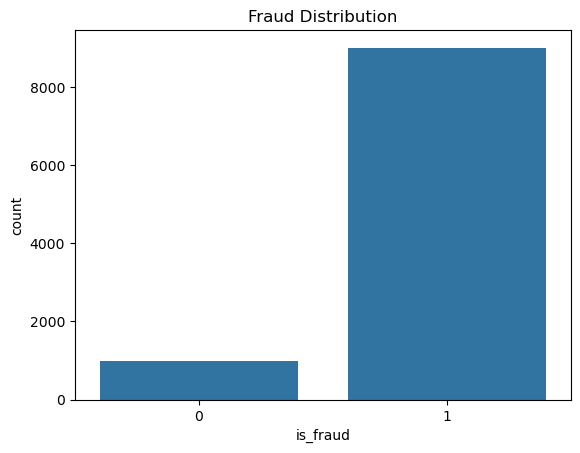

In [10]:
sns.countplot(x='is_fraud', data=df)
plt.title("Fraud Distribution")
plt.show()

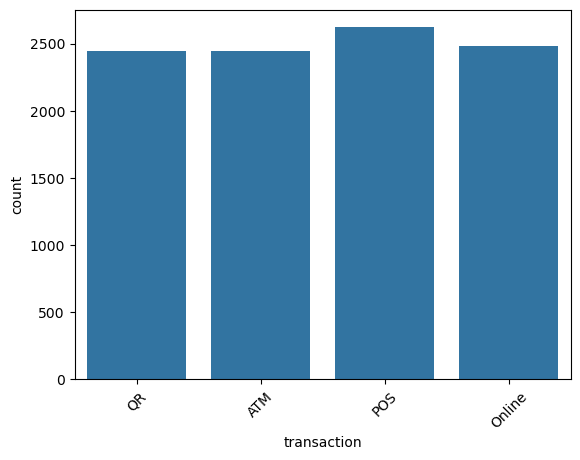

In [11]:
sns.countplot(x='transaction', data=df)
plt.xticks(rotation=45)
plt.show()

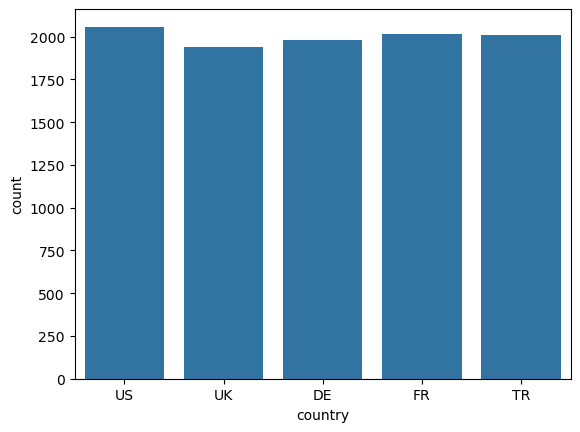

In [12]:
sns.countplot(x='country', data=df)
plt.show()

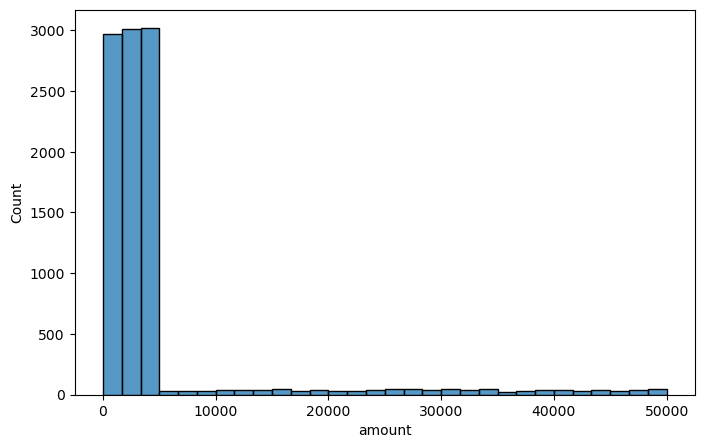

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['amount'], bins=30)
plt.show()

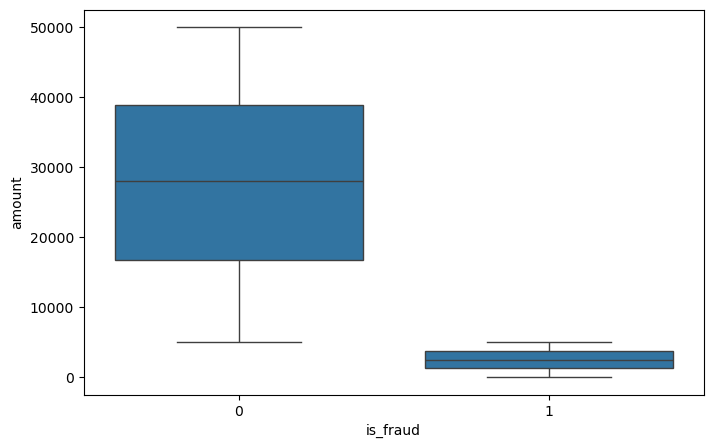

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x='is_fraud', y='amount', data=df)
plt.show()

In [16]:
le_transaction = LabelEncoder()
le_merchant = LabelEncoder()
le_country = LabelEncoder()
df['transaction'] = le_transaction.fit_transform(df['transaction'])
df['merchant'] = le_merchant.fit_transform(df['merchant'])
df['country'] = le_country.fit_transform(df['country'])

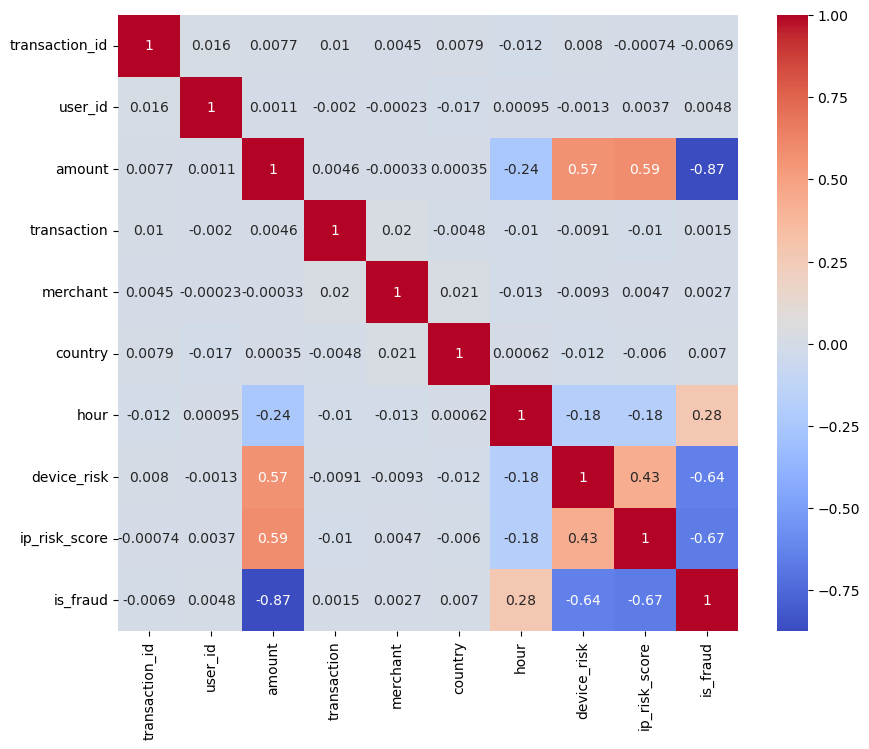

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

In [18]:
x = df.drop('is_fraud', axis=1)
y = df['is_fraud']

In [19]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [20]:
rf = RandomForestClassifier(random_state=42)

In [21]:
rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [22]:
y_pred = rf.predict(x_test)
y_prob = rf.predict_proba(x_test)[:,1]

In [23]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 1.0


In [24]:
precision = precision_score(y_test,y_pred)
print("Precision:",precision)

Precision: 1.0


In [25]:
recall = recall_score(y_test,y_pred)
print("Recall:",recall)

Recall: 1.0


In [26]:
f1 = f1_score(y_test,y_pred)
print("F1 Score:",f1)

F1 Score: 1.0


In [27]:
roc = roc_auc_score(y_test,y_prob)
print("ROC AUC:",roc)

ROC AUC: 1.0


In [28]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      1.00      1.00      1800

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



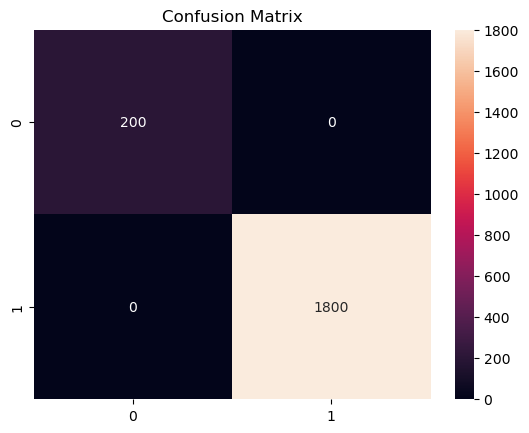

In [31]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [32]:
param_grid = {'n_estimators':[100,200],'max_depth':[5,10,20],'min_samples_split':[2,5],'min_samples_leaf':[1,2]}

In [33]:
grid = GridSearchCV(estimator=RandomForestClassifier(random_state=42),param_grid=param_grid,cv=5,scoring='f1',n_jobs=-1)
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 20], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [34]:
print(grid.best_params_)

{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [35]:
best_rf = grid.best_estimator_

In [36]:
y_pred_tuned = best_rf.predict(x_test)
print(classification_report(y_test,y_pred_tuned))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      1.00      1.00      1800

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [37]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [38]:
import shap

In [39]:
explainer = shap.TreeExplainer(best_rf)

In [40]:
shap_values = explainer.shap_values(x_test)

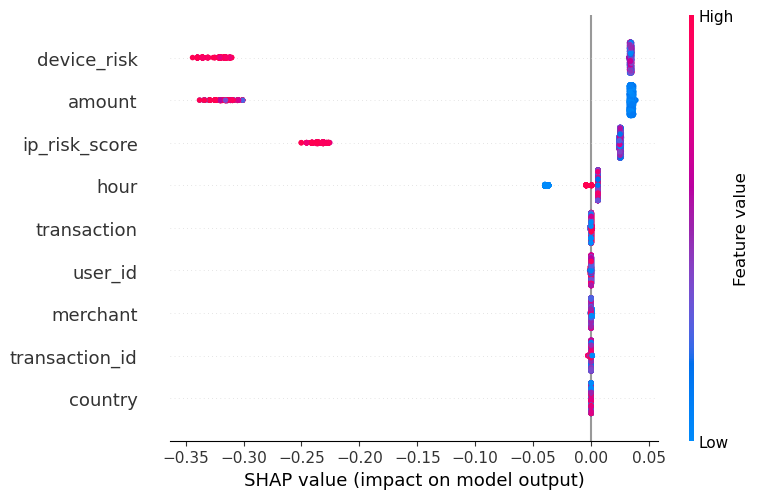

In [41]:
shap.summary_plot(shap_values[:,:,1],x_test)

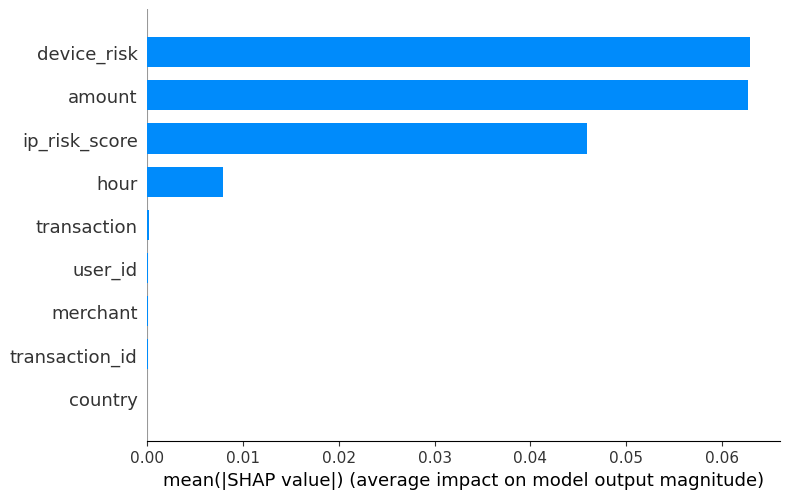

In [42]:
shap.summary_plot(shap_values[:,:,1],x_test,plot_type='bar')

In [43]:
transaction = x_test.iloc[[0]]
transaction

,transaction_id,user_id,amount,transaction,merchant,country,hour,device_risk,ip_risk_score
6047,5628,245,1553.45,3,0,3,11,0.475124,0.189771


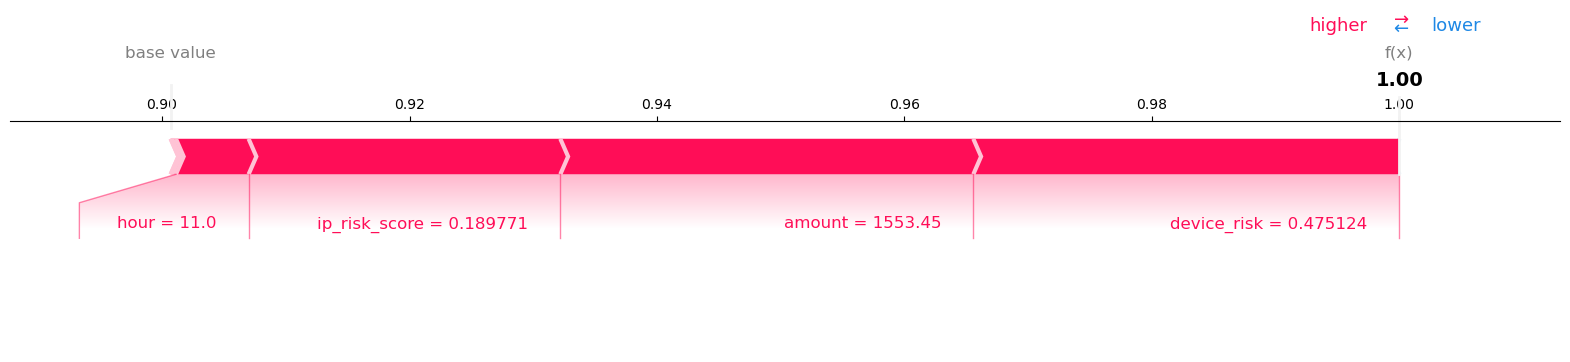

In [44]:
shap.force_plot(explainer.expected_value[1],shap_values[0,:,1],transaction,matplotlib=True)

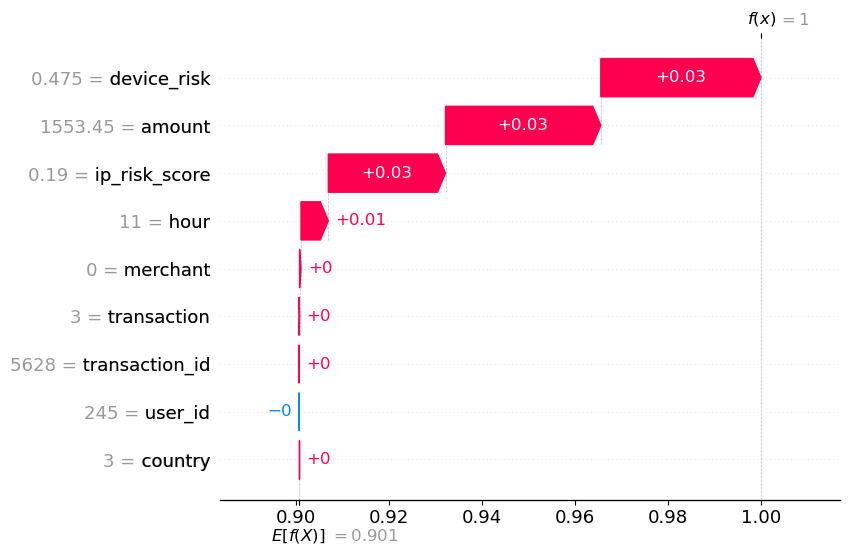

In [46]:
shap.plots.waterfall(shap.Explanation(values=shap_values[0,:,1],base_values=explainer.expected_value[1],data=transaction.iloc[0],feature_names=x_test.columns))

In [47]:
joblib.dump(best_rf,"bank_transaction_rf_model.pkl")

['bank_transaction_rf_model.pkl']

In [49]:
joblib.dump(le_transaction,"transaction_encoder.pkl")
joblib.dump(le_merchant,"merchant_encoder.pkl")
joblib.dump(le_country,"country_encoder.pkl")

['country_encoder.pkl']

In [50]:
model = joblib.load("bank_transaction_rf_model.pkl")

In [52]:
new_transaction = pd.DataFrame({
    'transaction_id':[1234],
    'user_id':[555],
    'amount':[25000],
    'transaction':[2],   
    'merchant':[1],      
    'country':[3],       
    'hour':[23],
    'device_risk':[0.92],
    'ip_risk_score':[0.89]
})

In [53]:
risk_score = best_rf.predict_proba(new_transaction)[0][0]
print("Fraud Pr

Fraud Probability: 1.0


In [55]:
if risk_score >= 0.8:
    risk = "High Risk"
elif risk_score >= 0.5:
    risk = "Medium Risk"
else:
    risk = "Low Risk"